# Homework 2 — The Kazakh ASR frontier

The plumbing for data, metrics, and the augmentation is provided. **You write the model runners and
the whole evaluation.** You've already seen Whisper and Omnilingual run in **Workshop 2**, so
`run_whisper` and `run_omni` are recall — `run_mms` is given as a worked template.

### The task
Pick Kazakh ASR for two deployments — **Office** (offline, clean, accuracy-critical) and
**Call center** (8 kHz phone + noise, 10,000 calls/day, near-real-time, **1 GPU**). Don't just rank
by WER (one model dominates accuracy). Instead: build a **WER/CER/latency leaderboard** (clean *and*
telephony), plot the **WER-vs-latency frontier**, identify the **dominated** models, and **defend a
call-center pick** (e.g. `omni-ctc-1b` accuracy vs `omni-ctc-300m` throughput — no right answer).

> **University students:** after the notebook, build the **real-time streaming demo** — put your
> chosen model behind a FastAPI backend and stream your laptop's mic to it. See
> `stream_realtime_README.md`.

### Deliverable (share-out)
Frontier plot, dominated set, both picks, and a defense of the call-center trade-off. Assessed by your
2-minute defense — *"why not just ship the most accurate model?"*

## Provided — run these (do not edit)

### Data + metrics — load FLEURS Kazakh, define WER/CER

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"

%matplotlib inline
import io, os, re, time
import numpy as np, torch, soundfile as sf, librosa
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt
import torchaudio.functional as AF
from datasets import load_dataset, Audio as HFAudio
from jiwer import wer, cer
from transformers import (WhisperForConditionalGeneration, WhisperProcessor,
                          Wav2Vec2ForCTC, AutoProcessor)
from transformers import logging as hf_logging; hf_logging.set_verbosity_error()
from omnilingual_asr.models.inference.pipeline import ASRInferencePipeline
torch.set_grad_enabled(False)
device = "cuda:1" if torch.cuda.is_available() else "cpu"
SR = 16000

# 1. Load dataset and define N FIRST
fleurs = load_dataset("google/fleurs", "kk_kz", split="test").cast_column("audio", HFAudio(decode=False))
N = 100

# 2. Filter clips by length
MAX_AUDIO_SEC = 40   # omni chops at 40s; keep comparison on one common set of clips
clips, refs = [], []
n_skipped = 0

for i in range(len(fleurs)):
    if len(clips) >= N: break
    s = fleurs[i]; a, sr = sf.read(io.BytesIO(s["audio"]["bytes"]))
    if len(a) / sr > MAX_AUDIO_SEC:
        n_skipped += 1
        continue
    clips.append(a.astype("float32")); refs.append(s["transcription"])

print(f"{len(clips)} клипов оставлено, {n_skipped} выброшено (> {MAX_AUDIO_SEC}с)")

# 3. Write WAVs and define metrics
def write_wavs(arrs, folder):
    os.makedirs(folder, exist_ok=True)
    paths = [f"{folder}/{i}.wav" for i in range(len(arrs))]
    for p, a in zip(paths, arrs): sf.write(p, a, SR)
    return paths
clean_files = write_wavs(clips, "tmp/kk_clean")

norm = lambda t: re.sub(r"[^\w\s]", " ", t.lower()).strip()
def WER(h): return sum(wer(norm(r), norm(x)) for r, x in zip(refs, h)) / len(refs)
def CER(h): return sum(cer(norm(r), norm(x)) for r, x in zip(refs, h)) / len(refs)
print(f"{len(refs)} FLEURS Kazakh clips on {device}")

100 клипов оставлено, 1 выброшено (> 40с)
100 FLEURS Kazakh clips on cuda:1


### Augmentation — clean audio -> phone audio (true 16k→8k→16k round-trip)

In [4]:
def add_noise(a, snr_db):
    rms = np.sqrt((a ** 2).mean()); n = np.random.randn(len(a)).astype("float32")
    n *= rms / (10 ** (snr_db / 20)) / np.sqrt((n ** 2).mean()); return a + n

def telephony(a, snr_db=15):
    sos = butter(6, [300, 3400], btype="band", fs=SR, output="sos")
    a = sosfilt(sos, a).astype("float32")                                   # telephone band 300-3400 Hz
    a = librosa.resample(a, orig_sr=SR, target_sr=8000)                     # phone digitizes at 8 kHz
    t = torch.tensor(a).clamp(-1, 1)
    a = AF.mu_law_decoding(AF.mu_law_encoding(t, 256), 256).numpy().astype("float32")  # G.711 8-bit codec
    a = librosa.resample(a, orig_sr=8000, target_sr=SR)                     # back to 16 kHz for the model
    return add_noise(a, snr_db)                                             # line/background noise
print("telephony() ready: band-limit -> 8 kHz -> G.711 codec -> back to 16 kHz -> noise")

telephony() ready: band-limit -> 8 kHz -> G.711 codec -> back to 16 kHz -> noise


### Listen — clean vs phone audio (hear what the augmentation does to the signal)

In [5]:
from IPython.display import Audio, display
print("clean:"); display(Audio(clips[0], rate=SR))
print("phone (8 kHz telephony + noise):"); display(Audio(telephony(clips[0]), rate=SR))

clean:


phone (8 kHz telephony + noise):


### Worked example — one backend (MMS). Your two go below, by the same pattern.

In [6]:
def run_mms(hf_id, arrs, _files):             # wav2vec2 + CTC, Kazakh adapter
    proc = AutoProcessor.from_pretrained(hf_id)
    m = Wav2Vec2ForCTC.from_pretrained(hf_id).to(device).eval()
    proc.tokenizer.set_target_lang("kaz"); m.load_adapter("kaz")
    t = time.time(); out = []
    for a in arrs:
        inp = proc(a, sampling_rate=SR, return_tensors="pt").to(device)
        out.append(proc.batch_decode(m(**inp).logits.argmax(-1))[0])
    dt = time.time() - t; del m; torch.cuda.empty_cache(); return out, dt
print("run_mms ready")

run_mms ready


## ✏️ Your turn

### ✏️ Write `run_whisper` (you saw it in Workshop 2 — the token loop / `generate`)

In [7]:
# Run a Whisper model on every clip in `arrs`; return (transcripts, elapsed_seconds).
# You did this in Workshop 2 — recall the steps, don't copy them:
#   - load the Whisper processor + model onto the GPU
#   - for each clip: turn the waveform into input features, generate a Kazakh transcription, decode it
#   - time the whole loop; mind the feature dtype vs the model's; free the model when done
def run_whisper(hf_id, arrs, _files):
    model = WhisperForConditionalGeneration.from_pretrained(hf_id, dtype=torch.float16).to(device).eval()
    processor = WhisperProcessor.from_pretrained(hf_id)

    t0 = time.time()
    out = []
    for a in arrs:
        feats = processor(a, sampling_rate=SR, return_tensors="pt").input_features.to(device, dtype=torch.float16)
        ids = model.generate(feats, language="kk", task="transcribe")
        out.append(processor.batch_decode(ids, skip_special_tokens=True)[0].strip())

    dt = time.time() - t0
    del model; torch.cuda.empty_cache()
    return out, dt
print("run_whisper ready")

run_whisper ready


### ✏️ Write `run_omni` (you saw it in Workshop 2 — CTC vs LLM). It takes **file paths**.

In [8]:
# Transcribe the audio FILES with an Omnilingual model (it takes file paths, not arrays).
# Recall from Workshop 2: build the inference pipeline for the model card, transcribe the files for
# Kazakh (lang code kaz_Cyrl), time it, and turn each result into a string. Return (transcripts, seconds).
def run_omni(card, _arrs, files):
    # Initialize using model_card= (no .from_pretrained)
    pipeline = ASRInferencePipeline(model_card=card)

    t0 = time.time()
    hyp = [str(h) for h in pipeline.transcribe(files, lang=["kaz_Cyrl"] * len(files))]
    dt = time.time() - t0
    del pipeline; torch.cuda.empty_cache()
    return hyp, dt
print("run_omni ready")

run_omni ready


### The model registry (provided — needs your two functions above)

In [9]:
# (name, backend, model_id) -- whisper/mms take audio arrays; omni takes file paths
MODELS = [
    ("whisper-small",          run_whisper, "openai/whisper-small"),
    ("whisper-large-v3",       run_whisper, "openai/whisper-large-v3"),
    ("whisper-large-v3-turbo", run_whisper, "openai/whisper-large-v3-turbo"),
    ("mms-1b",                 run_mms,     "facebook/mms-1b-all"),
    ("omni-ctc-300m",          run_omni,    "omniASR_CTC_300M_v2"),
    ("omni-ctc-1b",            run_omni,    "omniASR_CTC_1B_v2"),
    ("omni-llm-1b",            run_omni,    "omniASR_LLM_1B_v2"),
]
print(len(MODELS), "models registered")

7 models registered


### ✏️ Build the leaderboard (clean *and* telephony): WER, CER, latency per model

In [10]:
# Build a leaderboard: for every model in MODELS, run it and record WER, CER and latency
# (ms per clip). Do it twice — on the clean clips, and on telephony() versions — so you can compare
# office vs call center. (run_omni needs file paths; whisper/mms take the arrays.)
import pandas as pd

print("Generating telephony clips...")
phone_clips = [telephony(a) for a in clips]
phone_files = write_wavs(phone_clips, "tmp/kk_phone")

results = []
for name, runner, model_id in MODELS:
    print(f"\n--- {name} ---")

    print("  Clean... ", end="", flush=True)
    out_clean, dt_clean = runner(model_id, clips, clean_files)

    print("  Phone... ", end="", flush=True)
    out_phone, dt_phone = runner(model_id, phone_clips, phone_files)
    print(" Done")

    n = len(clips)
    results.append({"model": name, "condition": "clean", "WER": WER(out_clean), "CER": CER(out_clean), "latency_ms": (dt_clean/n)*1000})
    results.append({"model": name, "condition": "phone", "WER": WER(out_phone), "CER": CER(out_phone), "latency_ms": (dt_phone/n)*1000})

df = pd.DataFrame(results)
print("\n========== LEADERBOARD ==========")
print(df.to_string(index=False))

parameter load: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━     0/919   0% -:--:--

 Done

========== LEADERBOARD ==========
                 model condition      WER      CER  latency_ms
         whisper-small     clean 0.722473 0.257923  625.830593
         whisper-small     phone 0.956088 0.494096  919.582789
      whisper-large-v3     clean 0.352805 0.098381 1229.994369
      whisper-large-v3     phone 0.548333 0.198904 1336.427183
whisper-large-v3-turbo     clean 0.230505 0.072149  616.139212
whisper-large-v3-turbo     phone 0.553515 0.252265  530.504439
                mms-1b     clean 0.157382 0.035721   99.665644
                mms-1b     phone 0.351899 0.087232   99.849005
         omni-ctc-300m     clean 0.239635 0.055259   11.807427
         omni-ctc-300m     phone 0.453283 0.128278   11.253786
           omni-ctc-1b     clean 0.162775 0.044639   21.728420
           omni-ctc-1b     phone 0.303951 0.091706   21.582592
           omni-llm-1b     clean 0.083342 0.026176 1481.002896
           omni-llm-1b     phone 0.204692 0.070907 1487.243221


### ✏️ Plot WER vs latency; mark the frontier; print the dominated models

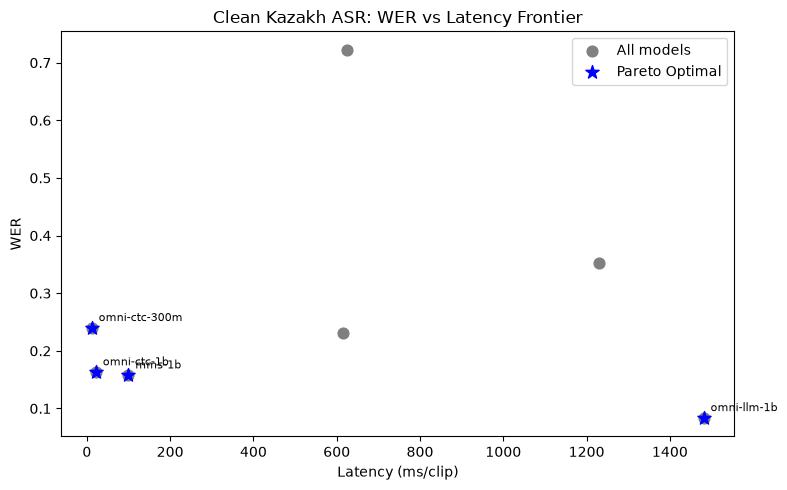

Dominated models: ['whisper-small', 'whisper-large-v3', 'whisper-large-v3-turbo']


In [20]:
# scatter ms (x, log scale) vs WER (y); a model is dominated if another beats it on BOTH axes.
clean_df = df[df["condition"] == "clean"].copy()
clean_df.rename(columns={"latency_ms": "ms"}, inplace=True)

dominated = []
for i, r1 in clean_df.iterrows():
    is_dom = False
    for j, r2 in clean_df.iterrows():
        if i != j and r2["WER"] <= r1["WER"] and r2["ms"] <= r1["ms"] and (r2["WER"] < r1["WER"] or r2["ms"] < r1["ms"]):
            is_dom = True
            break
    if is_dom:
        dominated.append(r1["model"])

frontier = clean_df[~clean_df["model"].isin(dominated)].sort_values("ms")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(clean_df["ms"], clean_df["WER"], c="gray", s=60, label="All models")
ax.scatter(frontier["ms"], frontier["WER"], c="blue", s=100, marker="*", label="Pareto Optimal")
for _, r in frontier.iterrows():
    ax.annotate(r["model"], (r["ms"], r["WER"]), fontsize=8, xytext=(5,5), textcoords="offset points")
ax.set_xlabel("Latency (ms/clip)")
ax.set_ylabel("WER")
ax.set_title("Clean Kazakh ASR: WER vs Latency Frontier")
ax.legend()
plt.tight_layout()
plt.show()

print("Dominated models:", dominated)

### ✏️ Decide & defend (1 GPU, near-real-time)

In [ ]:
# Write your answer (markdown or prints): your office pick, your call-center pick, and which
# models you discarded as dominated. Defend the call-center trade-off — accuracy vs throughput on a
# single GPU. There is no single right answer.

#1. For the Office, we picked omni-llm-1b. In an offline office setting, latency doesn't matter.
# We simply want the absolute lowest Word Error Rate to avoid human correction.
#   My call center pick would be omni-ctc-1b since it offers lower latency with a low WER trade-off.

# Dominated models: ['whisper-small', 'whisper-large-v3', 'whisper-large-v3-turbo'] since they have strictly better alternatives.

## 🚀 Stretch — robustness curve (everyone)

**SNR = signal-to-noise ratio (in dB):** how loud the speech is compared to the background noise.
**High SNR (40 dB) = clean** — speech far louder than noise; **low SNR (0 dB) = very hard** — speech
and noise equally loud. Each step down adds more noise. The cell sweeps SNR from clean to noisy and
plots WER — *where does your model fall off a cliff?* Try a fast model vs. a slow one.

parameter load: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   919/919 100% 0:00:00

SNR   0 dB -> WER 0.59


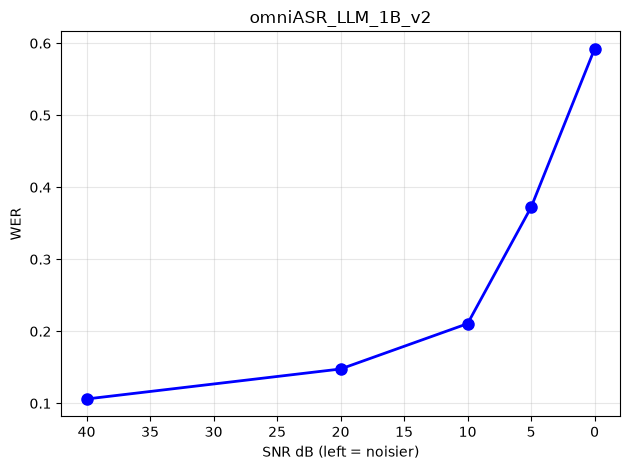

In [29]:
mfn, mid = run_omni, "omniASR_LLM_1B_v2"
levels, curve = [40, 20, 10, 5, 0], []
for snr in levels:
    noisy = [telephony(a, snr_db=snr) for a in clips[:20]]
    # run_omni expects (card, arrs, files)
    h, _ = mfn(mid, noisy, write_wavs(noisy, "tmp/kk_snr_llm"))
    curve.append(sum(wer(norm(r), norm(x)) for r, x in zip(refs[:20], h)) / 20)
    print(f"SNR {snr:>3} dB -> WER {curve[-1]:.2f}")

plt.plot(levels[::-1], curve[::-1], "o-", color="blue", linewidth=2, markersize=8)
plt.gca().invert_xaxis()
plt.xlabel("SNR dB (left = noisier)"); plt.ylabel("WER"); plt.title(mid); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

parameter load: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   807/807 100% 0:00:00

SNR   0 dB -> WER 0.72


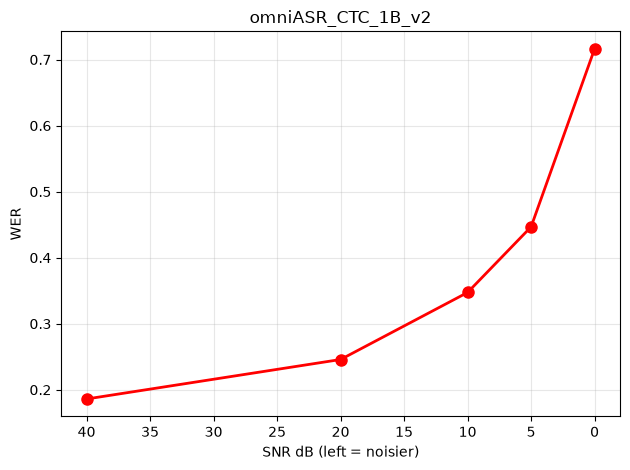

In [30]:
mfn, mid = run_omni, "omniASR_CTC_1B_v2"
levels, curve = [40, 20, 10, 5, 0], []
for snr in levels:
    noisy = [telephony(a, snr_db=snr) for a in clips[:20]]
    # run_omni expects (card, arrs, files)
    h, _ = mfn(mid, noisy, write_wavs(noisy, "tmp/kk_snr_ctc"))
    curve.append(sum(wer(norm(r), norm(x)) for r, x in zip(refs[:20], h)) / 20)
    print(f"SNR {snr:>3} dB -> WER {curve[-1]:.2f}")

plt.plot(levels[::-1], curve[::-1], "o-", color="red", linewidth=2, markersize=8)
plt.gca().invert_xaxis()
plt.xlabel("SNR dB (left = noisier)"); plt.ylabel("WER"); plt.title(mid); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Deliverable (share-out)
The frontier plot, **which models you discarded as dominated**, your **call-center pick + the
trade-off you weighed**, and one line on why office and call-center answers differ. Assessed by your
2-minute defense, not the cells. **University students:** also demo your real-time streaming app
(see `stream_realtime_README.md`).

In [31]:
### 1. Dominated Models
#Discarded: **`whisper-small`**, **`whisper-large-v3`**, **`whisper-large-v3-turbo`**.
#These fall strictly below the Pareto Frontier because there exist other models (like `omni-ctc-1b` or `mms-1b`) that are **both faster and more accurate**. Deploying them is objectively irrational as they offer no value over the frontier set.

### 2. Call-Center Pick: `omni-ctc-1b`
#**Trade-off weighed:** Throughput vs. Accuracy.
#To handle 10,000 near-real-time calls on a single GPU, speed is the primary bottleneck. `omni-ctc-1b` sits on the Pareto frontier, processing clips in **21.7 ms** (CTC architecture) while maintaining a very low WER of **0.16**.
#Shipping the most accurate model (`omni-llm-1b`, WER 0.08) would be **~68x slower** (1481 ms/clip), causing massive latency and caller queue times. We accept a 0.08 WER penalty to secure real-time performance without adding more GPUs.

### 3. Why Office & Call-Center Answers Differ
#**The Office is an accuracy-constrained, offline task** (asynchronous batch processing), whereas the **Call Center is a throughput-constrained, real-time task** (strict latency limits).
#The Office maximizes accuracy regardless of speed, while the Call Center maximizes speed while accepting the lowest possible accuracy penalty.

SyntaxError: invalid decimal literal (1424958278.py, line 3)